In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data_path = "melb_data_cleaned.csv"
df = pd.read_csv(data_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Suburb      10480 non-null  str    
 1   Rooms       10480 non-null  int64  
 2   Type        10480 non-null  str    
 3   Price       10480 non-null  float64
 4   Date        10480 non-null  str    
 5   Distance    10480 non-null  float64
 6   Bedroom2    10480 non-null  int64  
 7   Bathroom    10480 non-null  int64  
 8   Car         10480 non-null  int64  
 9   Landsize    10480 non-null  float64
 10  Lattitude   10480 non-null  float64
 11  Longtitude  10480 non-null  float64
 12  Regionname  10480 non-null  str    
 13  year        10480 non-null  int64  
 14  month       10480 non-null  int64  
 15  Type_h      10480 non-null  bool   
 16  Type_t      10480 non-null  bool   
 17  Type_u      10480 non-null  bool   
 18  Region_EM   10480 non-null  bool   
 19  Region_NM   10480 non-null  bool   


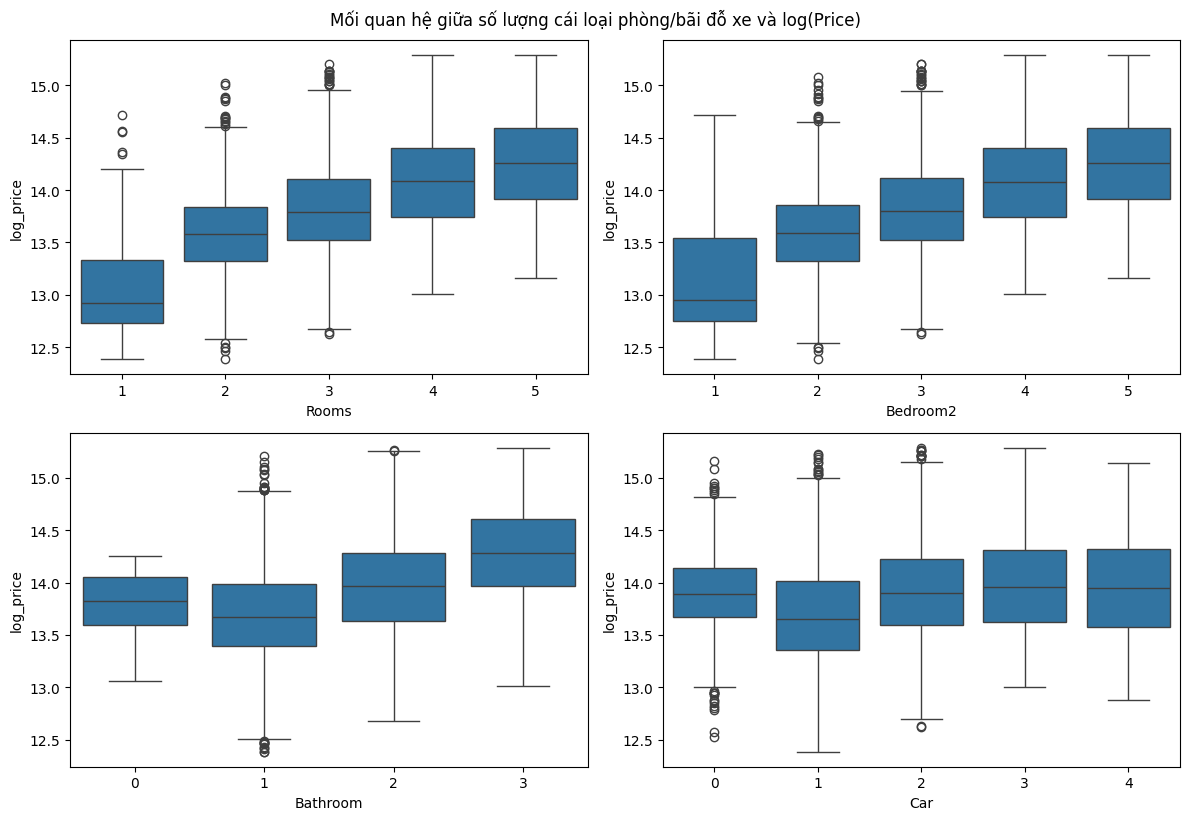

In [14]:
# 1. Phân tích mối quan hệ giữa tính chất vật lý và log(Price)
cols = ["Rooms", "Bedroom2", "Bathroom", "Car"]
plt.figure(figsize=(12,8))
for i, col in enumerate(cols):
    plt.subplot(2,2,i+1)
    sns.boxplot(x=df[col], y=df["log_price"])
plt.tight_layout()
plt.suptitle("Mối quan hệ giữa số lượng cái loại phòng/bãi đỗ xe và log(Price)",  y=1.02)
plt.show()

### Nhận xét:
Giữa log_price với Rooms\ Bedroom2\ Bathroom thể hiện rõ sự tuyến tính.<br>
Trong khi mối quan hệ so với Car lại không quá rõ ràng.</p>

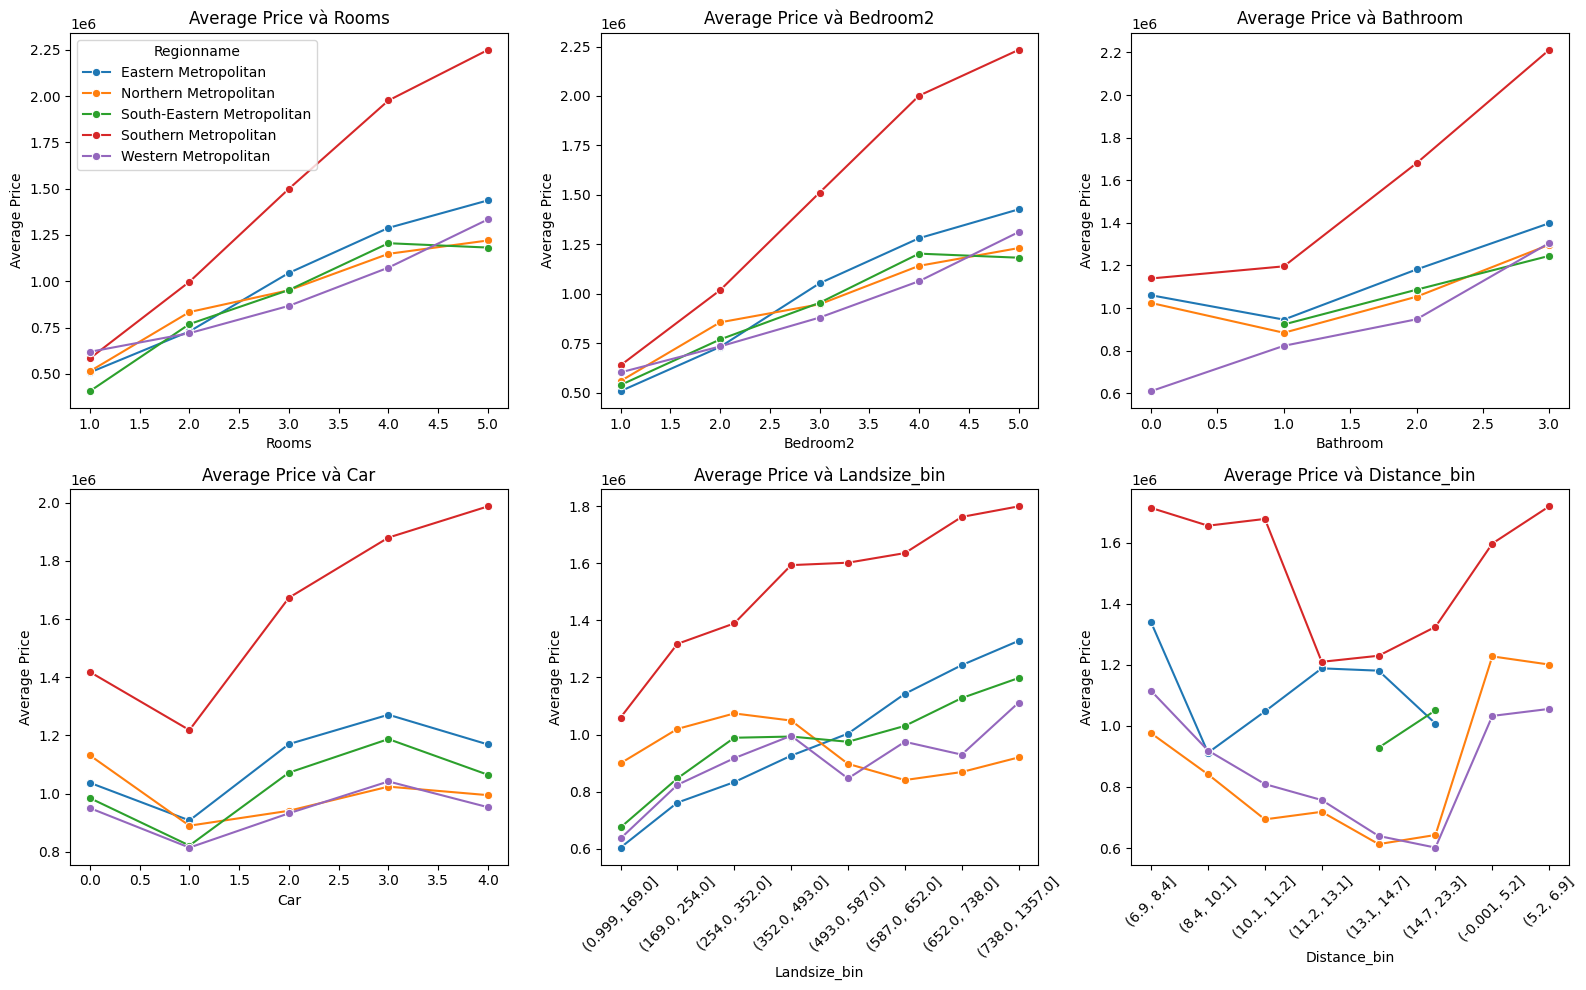

In [15]:
# 2. Vẽ biểu đồ quan hệ giữa Price và các đặc trưng, nhóm theo Regionname
df["Landsize_bin"] = pd.qcut(df["Landsize"], 8)
df["Distance_bin"] = pd.qcut(df["Distance"], 8)
features = ["Rooms","Bedroom2","Bathroom","Car","Landsize_bin","Distance_bin"]

fig, axes = plt.subplots(2,3,figsize=(16,10))
axes = axes.flatten()
for i, feature in enumerate(features):
    avg_price = (df.groupby(["Regionname", feature])["Price"].mean().reset_index())
    plot_data = avg_price.copy()
    if feature in ["Landsize_bin","Distance_bin"]:
        plot_data[feature] = plot_data[feature].astype(str)

    sns.lineplot(data=plot_data, x=feature, y="Price", hue="Regionname", marker="o", ax=axes[i])
    axes[i].set_title(f"Average Price và {feature}")
    axes[i].set_ylabel("Average Price")
    if i != 0:
        axes[i].get_legend().remove()
    if feature in ["Landsize_bin","Distance_bin"]:
        axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Nhận xét:
Quan hệ giữa giá và Rooms\ Bedroom2\ Bathroom\ Car hầu như vẫn giữ nguyên khi ta xem xét các nhóm Region riêng.<br>
Đặc biệt, ta thấy rõ giá trung bình giảm khi Car tăng từ 0-1, có xu hướng giảm tại 3-4<br>
Landsize tăng gần như tuyến tính, nhưng có ngoại lệ là Northern Metropolitan (Tăng nhưng sau đó giảm rồi tăng nhẹ)<br>
Tuy nhiên, ta khó thấy mối quan hệ giữa giá và khoảng cách đến CBD hơn.

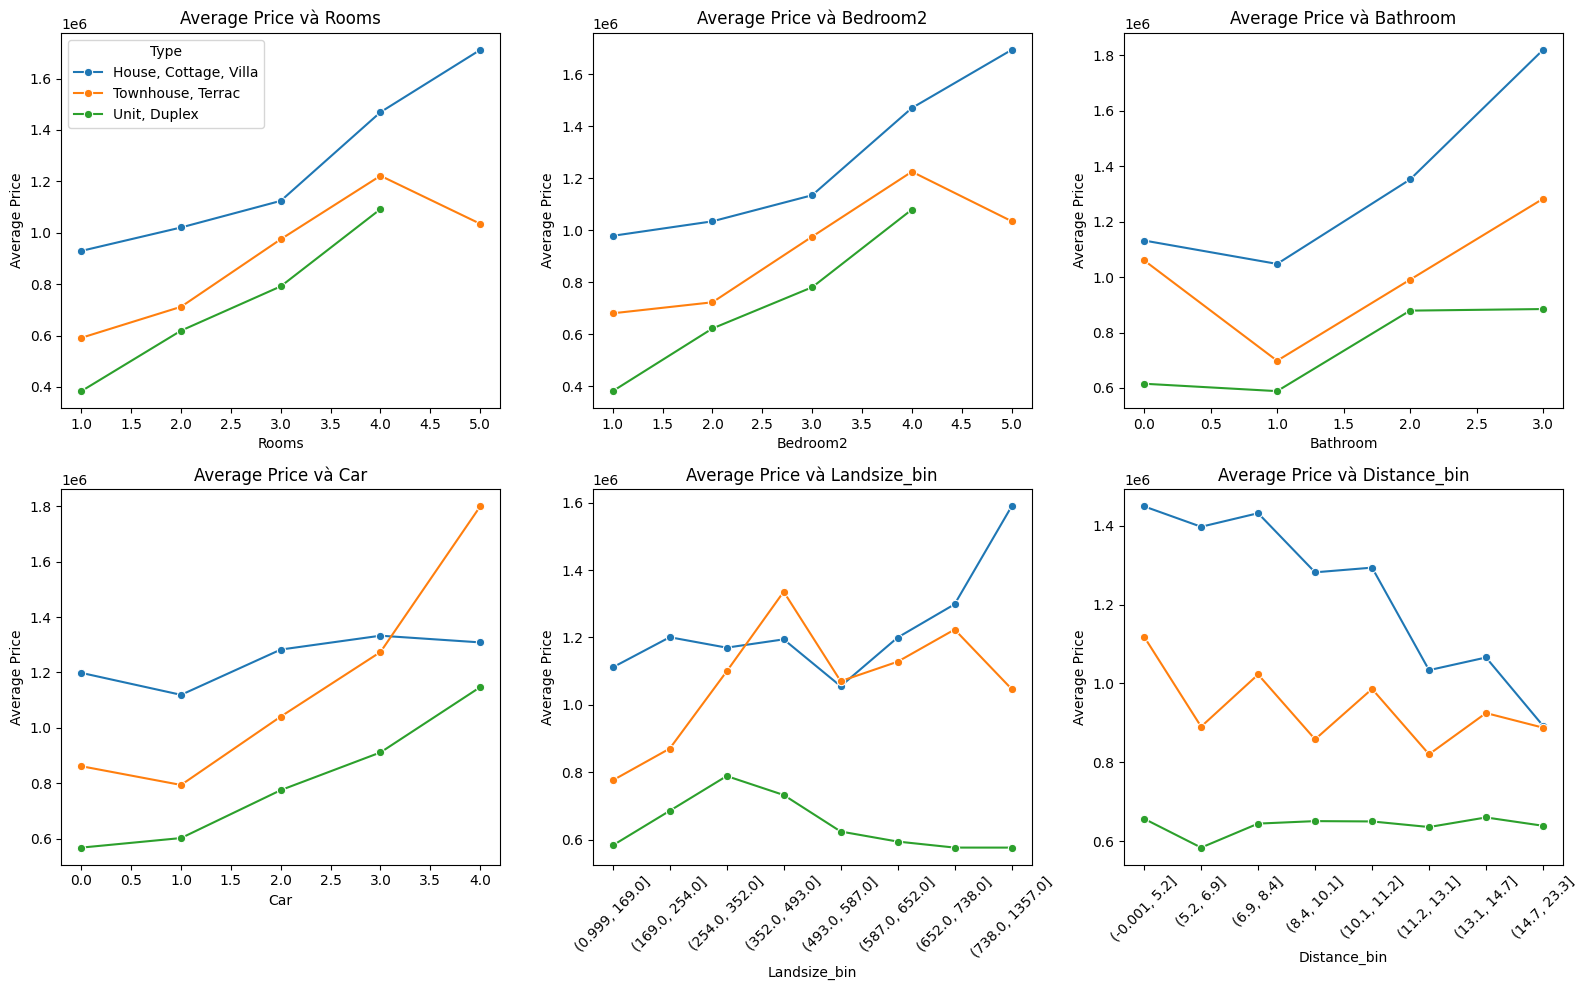

In [16]:
# 3. Vẽ biểu đồ quan hệ giữa Price và các đặc trưng, nhóm theo Type:
df["Type"] = df["Type"].replace({'h': 'House, Cottage, Villa', 'u': 'Unit, Duplex', 't': 'Townhouse, Terrac'})
df["Landsize_bin"] = pd.qcut(df["Landsize"], 8)
df["Distance_bin"] = pd.qcut(df["Distance"], 8)
features = ["Rooms","Bedroom2","Bathroom","Car","Landsize_bin","Distance_bin"]

fig, axes = plt.subplots(2,3,figsize=(16,10))
axes = axes.flatten()
for i, feature in enumerate(features):
    avg_price = (df.groupby(["Type", feature])["Price"].mean().reset_index())
    plot_data = avg_price.copy()
    if feature in ["Landsize_bin","Distance_bin"]:
        plot_data[feature] = plot_data[feature].astype(str)

    sns.lineplot(data=plot_data, x=feature, y="Price", hue="Type", marker="o", ax=axes[i])
    axes[i].set_title(f"Average Price và {feature}")
    axes[i].set_ylabel("Average Price")
    if i != 0:
        axes[i].get_legend().remove()
    if feature in ["Landsize_bin","Distance_bin"]:
        axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Nhận xét
Tương tự như trên, xu hướng của Rooms\ Bedroom2\ Bathroom\ Car thay đổi không quá nhiều.<br>
Landsize tăng nhưng phi tuyến tính, giá của Unit/Duplex lại không tăng nhiều theo diện tích.<br>
Distance thể hiện tương quan âm mạnh. Nhưng Giá của Unit/Duplex lại không thay đổi quá rõ rệt.

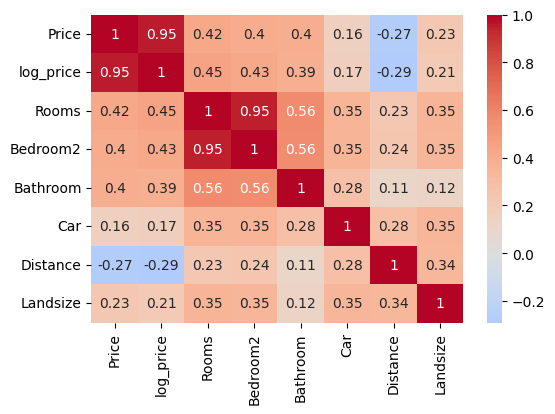

In [17]:
# 4. Phân tích tương quan
cols = ["Price","log_price","Rooms", "Bedroom2", "Bathroom","Car","Distance","Landsize"]
corr = df[cols].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.show()

### Nhận xét:
Các features hầu như thể hiện tương quan tuyến tính mạnh với log_price hơn so với Price.<br>
Các features với tương quan với log_price nổi bật củng cố cho những nhận xét trước đó:
- Rooms (0.45)
- Bedroom2 (0.43)
- Bathroom (0.39)
- Distance(-0.29)
- Landsize (0.21)

Correlation của cặp feature nổi bật: Corr[Rooms, Bedroom2] = 0.95. Thể hiện rằng 2 feature này có mối quan hệ cộng tính.<br>
Khi modeling, ta ưu tiên dùng Rooms vì tương quan giữa log_price so với Rooms là lớn hơn khi so với Bedroom2.<br>
Đồng thời, Rooms phản ánh tổng số phòng của ngôi nhà, mang tông tin tổng quát hơn Bedroom2
